# CRISPR like scRNA and scATAC analysis of mouse brain multiome data

This notebook analyzes a 10x Genomics single cell multiome dataset from an Alzheimer's disease mouse model. A single cell multiome experiment measures two kinds of information from the same nucleus. The RNA part tells us which genes are active. The ATAC part tells us which DNA regions are open and easier for regulatory proteins to reach.

The Alzheimer's mouse model is used to study brain changes that are related to neurodegeneration. In this project, we use the data to learn basic cell states from RNA and ATAC. Then we add virtual CRISPR labels so we can illustrate how Perturb-seq, CROP-seq, and CRISPR-sciATAC analyses work. These labels are not real guide RNA labels. They are a teaching device that mimics the structure of a pooled CRISPR screen.


## Background: CRISPR screens and single-cell readouts

### What is CRISPR?

CRISPR is a gene editing system. A **guide RNA (gRNA)** is a short synthetic
RNA that matches a specific DNA target sequence. It recruits the Cas9 protein
to that exact location in the genome, where Cas9 makes a cut. The cell's repair
machinery then disrupts that gene, effectively turning it off. This is called
a **knockout**.

In a **pooled CRISPR screen**, researchers design hundreds or thousands of
different gRNAs, each targeting a different gene. These are introduced into a
large cell population so that each cell receives one gRNA and therefore loses
one gene. Cells are then profiled to ask: what changed?

### Why combine CRISPR with single-cell sequencing?

Classic CRISPR screens measure only cell survival or growth, a very coarse
readout. Combining CRISPR with single-cell sequencing lets us ask much richer
questions for every individual cell:

- **Perturb-seq / CROP-seq**: Each cell's gRNA identity is sequenced alongside
  its full transcriptome (scRNA-seq). This reveals how knocking out a gene
  changes gene expression patterns across thousands of cells simultaneously.

- **CRISPR-sciATAC**: Each cell's gRNA identity is paired with its chromatin
  accessibility profile (scATAC-seq). This reveals how a perturbation changes
  which regulatory DNA regions are open, useful for understanding enhancers,
  transcription factor binding, and gene regulation.

### What about this notebook?

This dataset is a 10x Multiome mouse brain Alzheimer's dataset. It has **no
real CRISPR perturbations**. Instead, virtual perturbation labels (A and B)
are assigned based on a neuroinflammation gene score. This simulates the
*structure* of a Perturb-seq or CRISPR-sciATAC analysis so the same
differential expression and differential accessibility workflows can be
demonstrated. In a real screen, these labels would come from sequenced gRNA
identities in each cell.

## Project setup

This cell imports the main Python packages and sets the project folders. `scanpy` handles single cell objects and common RNA analysis. `anndata` stores matrices and cell metadata. `matplotlib` and `seaborn` make the figures. All figures are saved into the `images` folder inside the project directory.


In [1]:
import sys
print(sys.executable)
# Should print: /home/yourusername/miniforge3/envs/ad_multiome/bin/python

/home/yourusername/miniforge3/envs/ad_multiome/bin/python


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("/mnt/c/Users/chuab/Desktop/CRISPR_scRNA_scATAC")
FIGURE_DIR = DATA_DIR / "images"
FIGURE_DIR.mkdir(exist_ok=True)


In [3]:
# These helper functions live in the matching Python script.
# They keep the notebook readable while still making every step reproducible.
import sys

if str(DATA_DIR) not in sys.path:
    sys.path.insert(0, str(DATA_DIR))

from crispr_multiome_pipeline import (
    PEAK_BED_PATH,
    split_modalities,
    filter_rna,
    filter_atac,
    align_cells,
    plot_qc,
    preprocess_rna,
    preprocess_atac,
    plot_umap,
    add_virtual_perturbations,
    plot_rna_pathway_scores,
    run_rna_differential_expression,
    plot_rna_volcano,
    run_atac_differential_accessibility,
    plot_atac_volcano,
    add_atac_program_scores,
    plot_multiome_heatmap,
)

sns.set_theme(style="whitegrid", context="notebook")
sc.settings.verbosity = 2


## Data loading and preprocessing

The 10x H5 file contains both gene expression features and ATAC peak features. Genes are named units of the genome that can be copied into RNA. Peaks are DNA regions where the chromatin is open in at least some cells. Open peaks often mark enhancers, promoters, or other regulatory elements.

The code below loads the H5 file and keeps both feature types. It then splits the matrix into one RNA object and one ATAC object. The two objects start with the same cell barcodes, which is important because multiome data measure RNA and ATAC in the same nuclei.


In [4]:
h5_path = DATA_DIR / "Multiome_RNA_ATAC_Mouse_Brain_Alzheimers_AppNote_filtered_feature_bc_matrix.h5"

# Load the 10x multiome matrix.
# gex_only=False keeps ATAC peaks as well as gene expression features.
try:
    adata = sc.read_10x_h5(h5_path, gex_only=False)
except TypeError:
    adata = sc.read_10x_h5(h5_path)

adata.var_names_make_unique()
adata


reading /mnt/c/Users/chuab/Desktop/CRISPR_scRNA_scATAC/Multiome_RNA_ATAC_Mouse_Brain_Alzheimers_AppNote_filtered_feature_bc_matrix.h5
 (0:00:12)


/home/yourusername/miniforge3/envs/ad_multiome/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 33459 × 99200
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

In [5]:
# Split the full multiome object into RNA and ATAC AnnData objects.
adata_rna, adata_atac = split_modalities(adata)

print(adata_rna)
print(adata_atac)


RNA shape: (33459, 32286)
ATAC shape: (33459, 66914)
AnnData object with n_obs × n_vars = 33459 × 32286
    var: 'gene_ids', 'feature_types', 'genome', 'interval'
AnnData object with n_obs × n_vars = 33459 × 66914
    var: 'gene_ids', 'feature_types', 'genome', 'interval'


### Quality control

Quality control, often called QC, removes cells and features that are likely to be noisy. For RNA, low quality cells often have very few detected genes or very few total counts. A high fraction of mitochondrial RNA can also suggest a stressed or damaged cell. For ATAC, useful cells should have enough fragments and enough open peaks to describe their chromatin state.

The filters here are simple and transparent. They are meant to remove the weakest cells while keeping the workflow easy to understand. After separate RNA and ATAC QC, the notebook keeps only cells that passed both filters so that later RNA and ATAC labels still refer to the same nuclei.


filtered out 21 cells that have less than 200 genes expressed
filtered out 191 cells that have less than 500 counts
filtered out 5277 genes that are detected in less than 3 cells
RNA shape after QC: (33232, 27009)
ATAC shape after QC: (28466, 66914)
Shared cells after QC: 28287


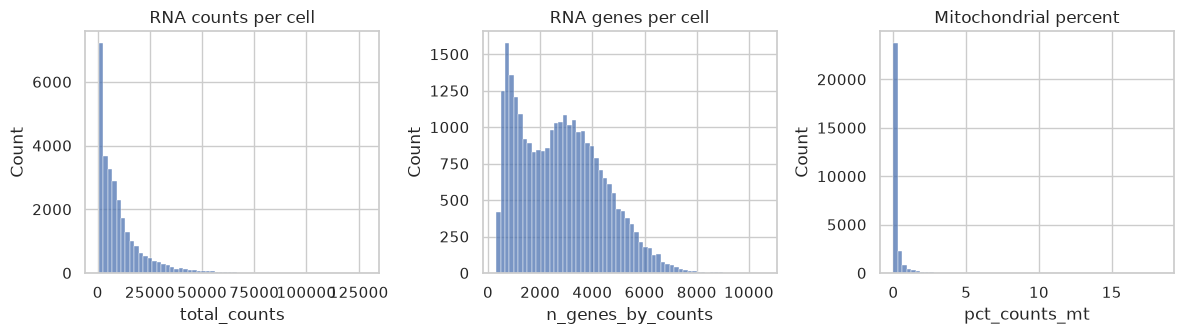

Saved /mnt/c/Users/chuab/Desktop/CRISPR_scRNA_scATAC/images/rna_qc_metrics.png


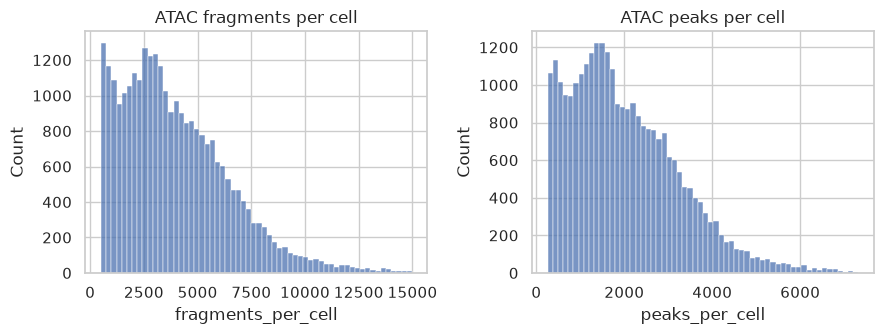

Saved /mnt/c/Users/chuab/Desktop/CRISPR_scRNA_scATAC/images/atac_qc_metrics.png


In [6]:
# Filter RNA cells and genes, then filter ATAC cells and peaks.
adata_rna = filter_rna(adata_rna)
adata_atac = filter_atac(adata_atac)

# Keep only nuclei that passed QC in both modalities.
adata_rna, adata_atac = align_cells(adata_rna, adata_atac)

# Save QC figures to the images folder.
plot_qc(adata_rna, adata_atac)


### Interpreting the QC figures

`rna_qc_metrics.png` shows how many RNA counts and genes are detected per cell, plus the mitochondrial percentage. Cells with very low RNA signal can blur true biological patterns, so they are removed. Cells with high mitochondrial percentage can reflect damaged nuclei or stressed cells.

`atac_qc_metrics.png` shows the number of ATAC fragments and detected peaks per cell. A cell with too few fragments has too little chromatin information for reliable analysis. A cell with very many fragments can sometimes be a doublet or another technical outlier.


## RNA analysis and clustering

For RNA, the notebook normalizes each cell so cells can be compared more fairly. It then applies a log transform, which makes very large counts less dominant. PCA, or principal component analysis, compresses thousands of genes into a smaller set of summary axes that capture major expression patterns. UMAP then places cells in two dimensions so similar cells appear near each other. Leiden clustering groups nearby cells into communities that may represent cell types or cell states.


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:03)
computing PCA
    with n_comps=50


/home/yourusername/miniforge3/envs/ad_multiome/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


    finished (0:00:01)
computing neighbors
    using 'X_pca' with n_pcs = 30


/home/yourusername/miniforge3/envs/ad_multiome/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished (0:00:25)
computing UMAP
    finished (0:00:19)


/mnt/c/Users/chuab/Desktop/CRISPR_scRNA_scATAC/crispr_multiome_pipeline.py:229: UserWarning: Leiden clustering failed with Please install the igraph package: `conda install -c conda-forge python-igraph` or `pip3 install igraph`.. Using KMeans labels in leiden_rna so the rest of the workflow can continue.
  warnings.warn(


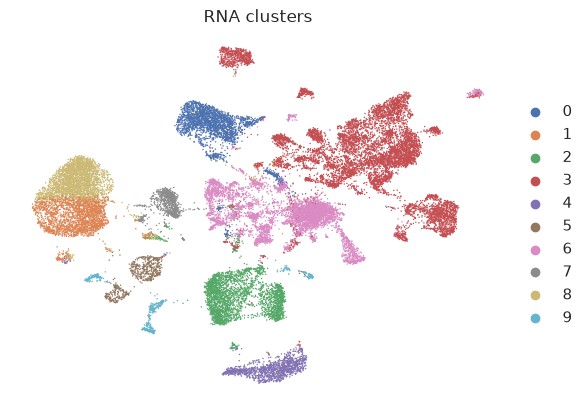

Saved /mnt/c/Users/chuab/Desktop/CRISPR_scRNA_scATAC/images/rna_umap_clusters.png


In [7]:
# Normalize RNA counts, log transform, run PCA, build a neighbor graph, run UMAP, and cluster cells.
adata_rna = preprocess_rna(adata_rna)

# Save a UMAP colored by RNA clusters.
plot_umap(adata_rna, "leiden_rna", "rna_umap_clusters.png", "RNA clusters")


### Interpreting the RNA cluster UMAP

Each dot is one nucleus. Dots that are close together have similar gene expression profiles. The cluster color shows groups found by the Leiden algorithm. If a cluster is separated from other clusters, it may represent a distinct cell type or a strong cell state. In brain data, clusters can often reflect neurons, glia, immune cells, or disease associated states.


## ATAC analysis and LSI

ATAC data are sparse because each cell only reports a small fraction of all possible open DNA regions. TF-IDF helps with this sparsity. The TF part asks how common a peak is inside one cell. The IDF part gives more weight to peaks that are informative across cells and less weight to peaks that are open almost everywhere. LSI uses truncated SVD on the TF-IDF matrix to find major chromatin accessibility patterns. After LSI, the notebook builds neighbors, runs UMAP, and clusters cells in the same general way as the RNA analysis.


computing neighbors
    finished (0:00:03)
computing UMAP
    finished (0:00:16)


/mnt/c/Users/chuab/Desktop/CRISPR_scRNA_scATAC/crispr_multiome_pipeline.py:229: UserWarning: Leiden clustering failed with Please install the igraph package: `conda install -c conda-forge python-igraph` or `pip3 install igraph`.. Using KMeans labels in leiden_atac so the rest of the workflow can continue.
  warnings.warn(


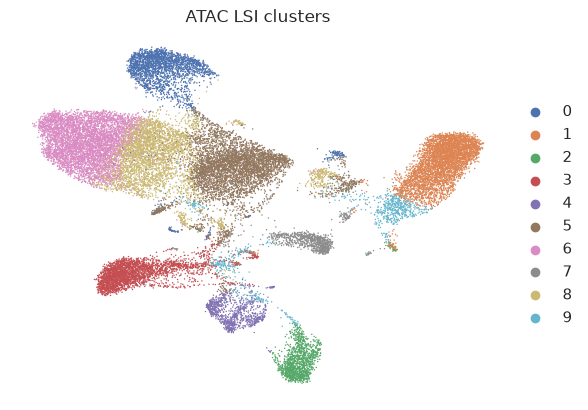

Saved /mnt/c/Users/chuab/Desktop/CRISPR_scRNA_scATAC/images/atac_umap_lsi_clusters.png


In [8]:
# Convert ATAC peak counts into a TF-IDF matrix, run LSI, build a neighbor graph, run UMAP, and cluster cells.
adata_atac = preprocess_atac(adata_atac)

# Save a UMAP colored by ATAC clusters.
plot_umap(adata_atac, "leiden_atac", "atac_umap_lsi_clusters.png", "ATAC LSI clusters")


### Interpreting the ATAC LSI UMAP

Each dot is the same kind of nucleus as in the RNA UMAP, but now distance is based on chromatin accessibility. Cells close together have similar open DNA regions. A cluster in this plot can represent a shared regulatory program. If the RNA and ATAC maps show related group structure, that suggests gene expression and chromatin accessibility are telling a consistent story.


### CRISPR screen methods: Perturb-seq, CROP-seq, and CRISPR-sciATAC

A pooled CRISPR screen puts many guide RNAs into a large population of cells. Each guide RNA points CRISPR machinery to a gene or regulatory region. After the experiment, we ask how cells with one guide differ from cells with another guide.

Perturb-seq links CRISPR guide RNAs to single cell RNA profiles. Its goal is to measure how a perturbation changes gene expression in many individual cells. The readout is a gene expression profile for each cell plus a guide identity. This is powerful because it shows which pathways respond to each perturbation.

CROP-seq is another way to connect guide RNA identity with single cell RNA sequencing. Its goal is similar to Perturb-seq. It lets researchers read the guide and the transcriptome from the same cell. This is powerful because many perturbations can be studied in one pooled experiment.

CRISPR-sciATAC combines CRISPR perturbation with single cell ATAC measurement. Its goal is to learn how perturbations change chromatin accessibility. The readout is a map of open DNA regions for cells carrying each guide. This is powerful because many disease genes act through regulatory DNA and transcription factor networks.

This Alzheimer mouse multiome dataset does not include true guide RNA labels. To illustrate the analysis structure, we create virtual perturbation labels. Perturbation A is assigned to cells with higher neuroinflammation score. Perturbation B is assigned to cells with lower neuroinflammation score. These labels are conceptual. In a real screen, the label would come from the guide RNA carried by each cell.


In [9]:
# Add conceptual guide-like labels based on a disease related RNA pathway score.
# The same cell barcodes are used in RNA and ATAC, so the labels can be copied across modalities.
adata_rna, adata_atac = add_virtual_perturbations(adata_rna, adata_atac)

adata_rna.obs[["virtual_perturbation", "neuroinflammation_score", "synaptic_score"]].head()


computing score 'neuroinflammation_score'
    finished (0:00:01)
computing score 'synaptic_score'
    finished (0:00:00)


,virtual_perturbation,neuroinflammation_score,synaptic_score
AAACAGCCAAGCGAGC-10,Perturbation B,-0.240993,-0.055338
AAACAGCCAAGCGATG-9,Perturbation B,-0.223940,0.629213
AAACAGCCAATAACCT-11,Perturbation B,-0.255220,0.473029
AAACAGCCAATGCCCG-8,Perturbation B,-0.259114,0.486114
AAACAGCCAATTGAGA-9,Perturbation A,0.170858,-0.139289


## CRISPR like analysis on RNA

In a real Perturb-seq or CROP-seq experiment, `virtual_perturbation` would be replaced by the true guide RNA identity. Here we treat the virtual labels as if they were guide labels. This lets us demonstrate the same questions: do the groups occupy different parts of the RNA map, which genes change between groups, and which pathways shift between groups.


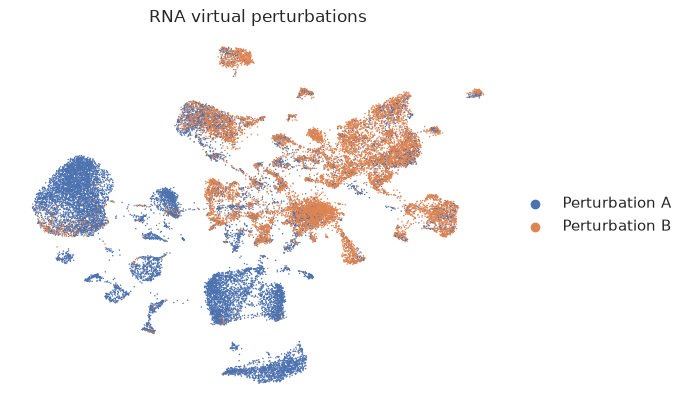

Saved /mnt/c/Users/chuab/Desktop/CRISPR_scRNA_scATAC/images/rna_umap_virtual_perturbations.png


/mnt/c/Users/chuab/Desktop/CRISPR_scRNA_scATAC/crispr_multiome_pipeline.py:448: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


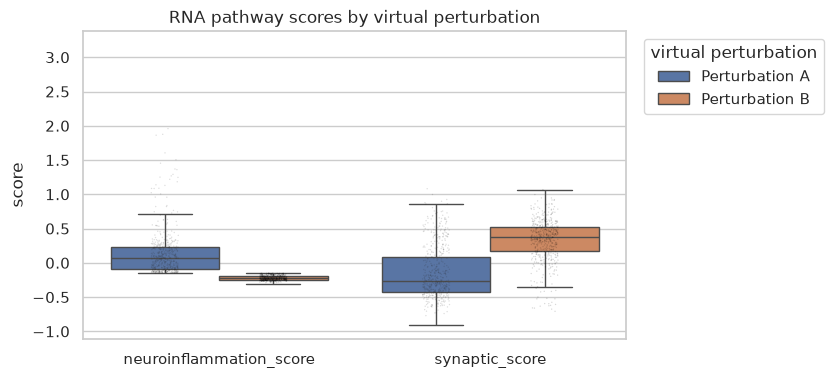

Saved /mnt/c/Users/chuab/Desktop/CRISPR_scRNA_scATAC/images/rna_pathway_scores_virtual_perturbations.png
RNA differential expression cluster: 3
ranking genes
    finished (0:00:06)
Saved /mnt/c/Users/chuab/Desktop/CRISPR_scRNA_scATAC/rna_de_perturbationA_vs_B.csv


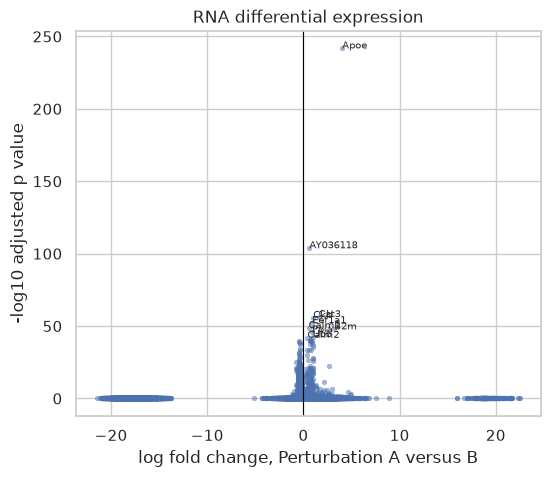

Saved /mnt/c/Users/chuab/Desktop/CRISPR_scRNA_scATAC/images/rna_de_perturbationA_vs_B_volcano.png


,gene,scores,logfoldchanges,pvals,pvals_adj,cluster
0,Apoe,33.556919,4.029345,7.135810e-247,1.927311e-242,3
1,AY036118,22.134727,0.614428,1.463951e-108,1.976993e-104,3
2,Cst3,16.455715,1.581517,7.631501e-61,6.870640e-57,3
3,Ckb,16.369770,1.015192,3.143968e-60,2.122886e-56,3
4,Eef1a1,15.831269,0.912100,1.893612e-56,1.022891e-52,3
5,Calm1,15.309366,0.533750,6.620589e-53,2.980258e-49,3
6,B2m,15.179336,3.192549,4.846634e-52,1.870039e-48,3
7,Ppia,14.846189,0.869774,7.363725e-50,2.486086e-46,3
8,Ubb,14.324060,0.958023,1.548066e-46,4.645745e-43,3
9,Calm2,14.244295,0.409890,4.864302e-46,1.313799e-42,3


In [10]:
# Plot RNA UMAP colored by virtual perturbation labels.
plot_umap(
    adata_rna,
    "virtual_perturbation",
    "rna_umap_virtual_perturbations.png",
    "RNA virtual perturbations",
)

# Plot pathway scores for the virtual groups.
plot_rna_pathway_scores(adata_rna)

# Run differential expression inside one RNA cluster, then save a volcano plot.
rna_de = run_rna_differential_expression(adata_rna)
plot_rna_volcano(rna_de)

rna_de.head(10)


### Interpreting the RNA CRISPR-like figures

`rna_umap_virtual_perturbations.png` shows that Perturbation A and Perturbation B
do **not** form cleanly separated regions, both groups are broadly intermixed
across the UMAP. This is expected, because the virtual labels were assigned by
a continuous neuroinflammation score rather than a discrete biological state.
The large blue-dominated cluster on the left likely represents a distinct cell
population (possibly neurons or oligodendrocytes) that skews toward Perturbation A,
while the denser central and upper cloud is more mixed. This pattern suggests
the neuroinflammation signal is present across multiple cell states rather than
confined to one cell type.

`rna_pathway_scores_virtual_perturbations.png` confirms the label assignment
worked as intended: Perturbation A has a higher neuroinflammation score than
Perturbation B, as expected by design. The synaptic score shows the opposite
pattern, Perturbation B scores higher, which suggests that cells with lower
inflammatory tone tend to have stronger neuronal/synaptic gene expression.
This is biologically consistent with the known inverse relationship between
neuroinflammation and synaptic gene programs in Alzheimer's models, where
activated glial states are associated with reduced neuronal gene expression.

`rna_de_perturbationA_vs_B_volcano.png` compares differential expression
within cluster 3 between the two virtual groups. The most significantly
upregulated gene in Perturbation A is **Apoe** (log fold change ~4.0,
-log10 adjusted p-value ~240), which is a well-established Alzheimer's risk
gene and a marker of disease-associated microglia and astrocytes. Other top
hits — **B2m** (log FC ~3.2), **Cst3**, **Ckb**, and **Calm1/Calm2**, are
enriched in glial and microglial activation states. The large leftward cloud
of points with near-zero -log10 p-values represents genes with no significant
difference between groups. The asymmetry of significant hits toward the right
(Perturbation A higher) is consistent with the neuroinflammation-high
definition of Perturbation A. In a real Perturb-seq or CROP-seq experiment,
this same volcano would show the direct transcriptional consequences of
a CRISPR guide targeting a gene of interest, such as *Apoe* itself.

## CRISPR like analysis on ATAC

In a real CRISPR-sciATAC experiment, each cell would carry a guide RNA and the ATAC profile would show how that guide changes open chromatin. Here we use the same virtual perturbation labels. The main question is whether Perturbation A and Perturbation B differ in which peaks are open.

The peak BED file provides genomic coordinates for each ATAC peak. This notebook adds those coordinates to the differential accessibility table. Nearest gene annotation needs a mouse gene TSS table, and motif annotation needs genome sequence plus a motif database. Because those extra files are not in this folder, the notebook reports coordinates and leaves clear columns that say the gene and motif steps were not run.


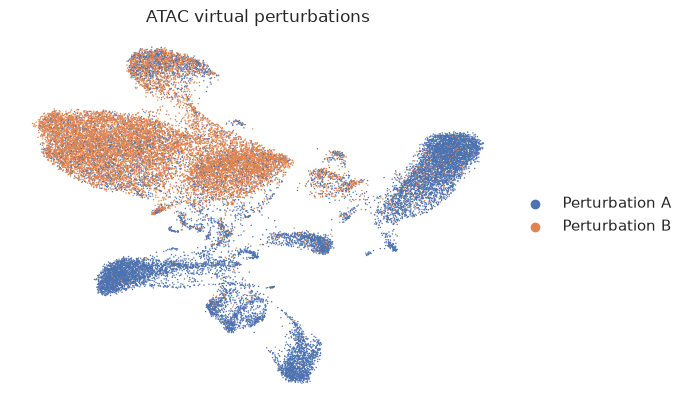

Saved /mnt/c/Users/chuab/Desktop/CRISPR_scRNA_scATAC/images/atac_umap_virtual_perturbations.png
ATAC differential accessibility cluster: 6
Saved /mnt/c/Users/chuab/Desktop/CRISPR_scRNA_scATAC/atac_diff_peaks_perturbationA_vs_B.csv


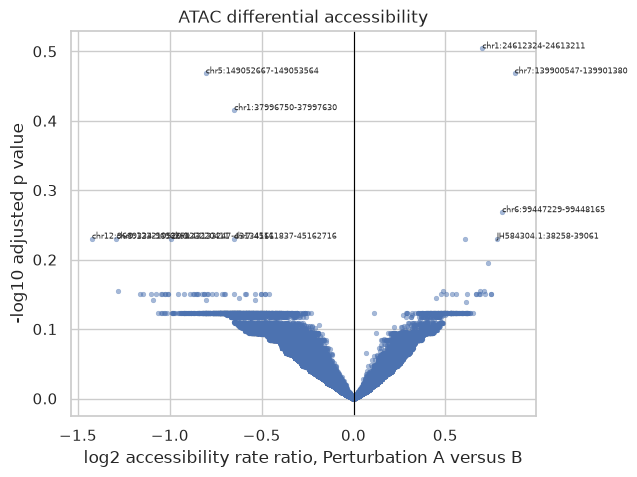

Saved /mnt/c/Users/chuab/Desktop/CRISPR_scRNA_scATAC/images/atac_diff_peaks_perturbationA_vs_B_volcano.png


,peak,cluster,open_cells_A,open_cells_B,cells_A,cells_B,accessibility_rate_A,accessibility_rate_B,rate_difference_A_minus_B,log2_rate_ratio_A_vs_B,z_score,p_value,p_value_adj,chrom,start,end,peak_width,nearest_gene,motif_annotation,annotation_note
21153,chr1:24612324-24613211,6,74.0,330.0,599,4574,0.123539,0.072147,0.051392,0.700985,4.407848,0.000010,0.313208,chr1,24612324,24613211,887,not annotated,not run,Coordinates come from the 10x BED file. Neares...
27014,chr5:149052667-149053564,6,41.0,581.0,599,4574,0.068447,0.127022,-0.058575,-0.804613,-4.144724,0.000034,0.340223,chr5,149052667,149053564,897,not annotated,not run,Coordinates come from the 10x BED file. Neares...
1690,chr7:139900547-139901380,6,37.0,133.0,599,4574,0.061770,0.029077,0.032692,0.877039,4.220243,0.000024,0.340223,chr7,139900547,139901380,833,not annotated,not run,Coordinates come from the 10x BED file. Neares...
29033,chr1:37996750-37997630,6,62.0,769.0,599,4574,0.103506,0.168124,-0.064618,-0.650117,-4.049889,0.000051,0.384314,chr1,37996750,37997630,880,not annotated,not run,Coordinates come from the 10x BED file. Neares...
4005,chr6:99447229-99448165,6,38.0,146.0,599,4574,0.063439,0.031920,0.031520,0.808925,3.916487,0.000090,0.539093,chr6,99447229,99448165,936,not annotated,not run,Coordinates come from the 10x BED file. Neares...
18916,chr9:43133247-43134161,6,19.0,334.0,599,4574,0.031720,0.073021,-0.041302,-0.992761,-3.769570,0.000164,0.588476,chr9,43133247,43134161,914,not annotated,not run,Coordinates come from the 10x BED file. Neares...
2745,JH584304.1:38258-39061,6,36.0,141.0,599,4574,0.060100,0.030826,0.029274,0.779915,3.706068,0.000211,0.588476,JH584304.1,38258,39061,803,not annotated,not run,Coordinates come from the 10x BED file. Neares...
463,chr12:9689334-9690254,6,4.0,159.0,599,4574,0.006678,0.034762,-0.028084,-1.424336,-3.699794,0.000216,0.588476,chr12,9689334,9690254,920,not annotated,not run,Coordinates come from the 10x BED file. Neares...
28167,chr7:45161837-45162716,6,53.0,662.0,599,4574,0.088481,0.144731,-0.056250,-0.651849,-3.750891,0.000176,0.588476,chr7,45161837,45162716,879,not annotated,not run,Coordinates come from the 10x BED file. Neares...
6749,chr9:123219520-123220411,6,7.0,197.0,599,4574,0.011686,0.043070,-0.031383,-1.291110,-3.710931,0.000206,0.588476,chr9,123219520,123220411,891,not annotated,not run,Coordinates come from the 10x BED file. Neares...


In [11]:
# Plot ATAC UMAP colored by virtual perturbation labels.
plot_umap(
    adata_atac,
    "virtual_perturbation",
    "atac_umap_virtual_perturbations.png",
    "ATAC virtual perturbations",
)

# Compare accessibility rates between virtual groups inside one ATAC cluster.
atac_da = run_atac_differential_accessibility(adata_atac)
plot_atac_volcano(atac_da)

atac_da.head(10)


### Interpreting the ATAC CRISPR-like figures

`atac_umap_virtual_perturbations.png` shows considerably more spatial
separation between Perturbation A and Perturbation B than was seen in the
RNA UMAP. The upper-left region is dominated by Perturbation B (orange),
while Perturbation A (blue) occupies the right lobe and the lower clusters.
This suggests that the two virtual groups have meaningfully different chromatin
accessibility programs, cells assigned to each group not only differ in gene
expression (RNA) but also in which regulatory DNA regions are open. This
cross-modal consistency strengthens the biological interpretation.

`atac_diff_peaks_perturbationA_vs_B_volcano.png` compares peak accessibility
within ATAC cluster 6 between the two groups. The x-axis range is narrow
(roughly -1.5 to +1.0 log2 rate ratio) and the adjusted p-values are modest
(max ~0.5), indicating that ATAC differences are subtler and less statistically
powered than the RNA differences, this is typical, as chromatin accessibility
changes are often smaller in magnitude than transcriptional changes. The most
significant peak **more open in Perturbation A** is `chr1:24612324-24613211`
(log2 ratio +0.70, adj. p ~0.31), followed by `chr7:139900547-139901380`
(+0.88) and `chr6:99447225-99448165` (+0.81). The most significant peaks
**more open in Perturbation B** are `chr5:149052667-149053564` (-0.80),
`chr1:37996750-37997630` (-0.65), and `chr9:43133247-43134161` (-0.99).
None of the peaks reach an adjusted p-value below 0.05, meaning these are
candidates rather than high-confidence hits, a consequence of the virtual
label design and the within-cluster sample size (599 vs. 4574 cells).

The differential peak table provides chromosome coordinates and peak widths
(~800–940 bp, consistent with typical open chromatin peaks) for all top hits.
All peaks are currently listed as `not annotated` for nearest gene and
`not run` for motif annotation, because mouse TSS and motif database files
were not provided. To extend this analysis, add a mouse mm10 TSS BED file to
link each peak to its nearest gene, and run motif scanning with a tool such
as `pyjaspar` or `HOMER` to identify candidate transcription factors whose
binding sites overlap these differentially accessible regions. In a real
CRISPR-sciATAC experiment, this annotation step is where the mechanistic
story emerges, connecting a CRISPR perturbation to specific regulatory
elements and the transcription factors that act through them.

Note: Since 10x Cell Ranger ARC already did that annotation using the mm10 GENCODE reference during the pipeline run, the atac_peak_annotation.tsv file gives you that mapping directly.

### Linking CRISPR like perturbations across RNA and ATAC

A real CRISPR multiome study would trace each guide through both gene expression and chromatin accessibility. This is useful because expression shows what genes changed, while ATAC shows which regulatory elements may help drive those changes. If both modalities point to the same pathway, the biological interpretation is stronger.

The code below creates ATAC program scores from peaks that are more open in each virtual perturbation group. It then combines those ATAC scores with RNA pathway scores in one heatmap.


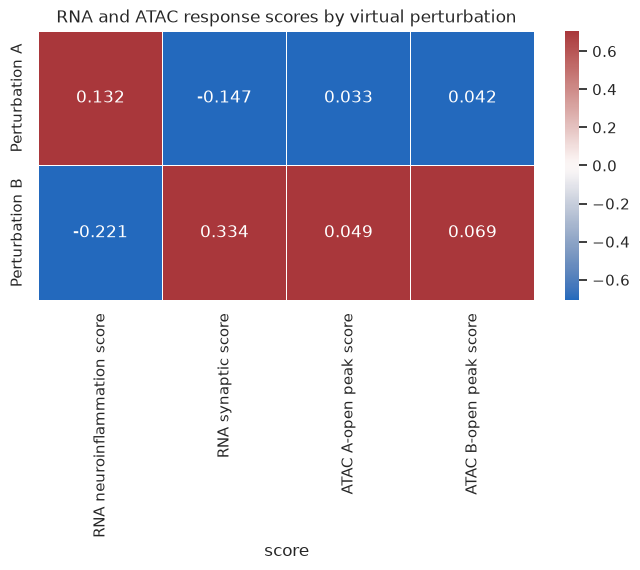

Saved /mnt/c/Users/chuab/Desktop/CRISPR_scRNA_scATAC/images/multiome_virtual_perturbation_pathway_heatmap.png


,RNA neuroinflammation score,RNA synaptic score,ATAC A-open peak score,ATAC B-open peak score
virtual_perturbation,,,,
Perturbation A,0.132403,-0.146754,0.033082,0.041892
Perturbation B,-0.220891,0.333883,0.049125,0.068573


In [12]:
# Create ATAC scores from top differential peaks and link them with RNA pathway scores.
add_atac_program_scores(adata_atac, atac_da)
summary_scores = plot_multiome_heatmap(adata_rna, adata_atac)
summary_scores


### Interpreting the linked RNA and ATAC heatmap

`multiome_virtual_perturbation_pathway_heatmap.png` summarizes group averages. Rows are the virtual perturbation groups. Columns are RNA pathway scores and ATAC peak program scores. The numbers inside the cells are the group means. The colors show whether each value is high or low relative to the other group.

If Perturbation A has both higher RNA neuroinflammation score and higher accessibility at A-open peaks, the RNA and ATAC sides agree that Perturbation A is linked to an inflammatory regulatory state. If the RNA and ATAC signals disagree, that can mean the response is complex, delayed, or spread across different cell types.


## Summary and future work

Perturb-seq and CROP-seq measure how CRISPR perturbations change single cell gene expression. CRISPR-sciATAC measures how perturbations change chromatin accessibility at regulatory DNA regions. All three methods connect a perturbation label to a single cell readout.

In this project, we loaded a mouse brain multiome dataset, split it into RNA and ATAC, ran QC, built RNA PCA and ATAC LSI embeddings, made UMAPs and clusters, and created virtual CRISPR like labels based on a neuroinflammation score. We then used those labels to demonstrate RNA differential expression, ATAC differential accessibility, pathway scoring, and a simple RNA plus ATAC response heatmap.

The main limitation is that the labels are simulated from the data. They are not real guide RNA identities. If real CRISPR guide labels become available for a neurodegeneration experiment, the same workflow can be repeated with true guide identities. The next steps would be to test each guide separately, add cell type labels, link peaks to genes with a mouse TSS annotation, and scan peak sequences for transcription factor motifs.


In [13]:
# Optional save step for processed objects.
# These files let you reopen the processed RNA and ATAC objects without rerunning every step.
adata_rna.write(DATA_DIR / "processed_rna_virtual_crispr.h5ad")
adata_atac.write(DATA_DIR / "processed_atac_virtual_crispr.h5ad")

sorted(path.name for path in FIGURE_DIR.glob("*.png"))


['atac_diff_peaks_perturbationA_vs_B_volcano.png',
 'atac_qc_metrics.png',
 'atac_umap_lsi_clusters.png',
 'atac_umap_virtual_perturbations.png',
 'multiome_virtual_perturbation_pathway_heatmap.png',
 'rna_de_perturbationA_vs_B_volcano.png',
 'rna_pathway_scores_virtual_perturbations.png',
 'rna_qc_metrics.png',
 'rna_umap_clusters.png',
 'rna_umap_virtual_perturbations.png']

## Transcription Factor Motif Scanning with HOMER

To understand *which transcription factors (TFs) may be driving* the 
differential chromatin accessibility between Perturbation A and B, we scan 
the top differential peaks for known TF binding motifs using HOMER 
(Hypergeometric Optimization of Motif EnRichment).

The top peaks more open in each group are exported as BED files and passed 
to HOMER's `findMotifsGenome.pl`. HOMER extracts the DNA sequences at those 
coordinates from the mm10 genome, then statistically compares enriched 
sequence motifs against a database of known vertebrate TF binding profiles.

- **Perturbation A peaks** (neuroinflammation-high): expected to enrich for 
  inflammatory TF motifs such as NF-κB, IRF, and PU.1
- **Perturbation B peaks** (synaptic/neuronal): expected to enrich for 
  neuronal TF motifs such as NEUROD, MEF2, and SOX family

Results are saved to `homer_motifs_perturbation_A/` and 
`homer_motifs_perturbation_B/`. Open `knownResults.html` in either folder 
in a browser for a full ranked motif report. In a real CRISPR-sciATAC 
experiment, this step connects a CRISPR perturbation directly to the 
regulatory elements and transcription factor networks it disrupts.

In [14]:
import subprocess
from pathlib import Path

HOMER_BIN = Path.home() / "miniforge3/envs/ad_multiome/share/homer/bin"

def run_motif_scanning(atac_da, data_dir, group="A", top_n=500):
    data_dir = Path(data_dir)
    
    # Step 1: filter top peaks for the group
    if group == "A":
        peaks = atac_da[atac_da["log2_rate_ratio_A_vs_B"] > 0].nsmallest(top_n, "p_value")
    else:
        peaks = atac_da[atac_da["log2_rate_ratio_A_vs_B"] < 0].nsmallest(top_n, "p_value")
    
    # Step 2: save as BED file (chr, start, end, name, score, strand)
    bed_path = data_dir / f"perturbation_{group}_peaks.bed"
    peaks[["chrom", "start", "end", "peak"]].assign(score=0, strand=".") \
        .to_csv(bed_path, sep="\t", header=False, index=False)
    print(f"Wrote {len(peaks)} peaks → {bed_path}")
    
    # Step 3: call HOMER
    out_dir = data_dir / f"homer_motifs_perturbation_{group}"
    out_dir.mkdir(exist_ok=True)
    result = subprocess.run([
        str(HOMER_BIN / "findMotifsGenome.pl"),
        str(bed_path), "mm10", str(out_dir),
        "-size", "given", "-mask", "-p", "4", "-mset", "vertebrates"
    ], capture_output=True, text=True)
    print(result.stdout[-1000:])
    if result.returncode != 0:
        print("ERROR:", result.stderr[-500:])
    return out_dir

homer_dir_A = run_motif_scanning(atac_da, DATA_DIR, group="A")
homer_dir_B = run_motif_scanning(atac_da, DATA_DIR, group="B")

Wrote 500 peaks → /mnt/c/Users/chuab/Desktop/CRISPR_scRNA_scATAC/perturbation_A_peaks.bed

Wrote 500 peaks → /mnt/c/Users/chuab/Desktop/CRISPR_scRNA_scATAC/perturbation_B_peaks.bed



In [17]:
def read_homer_known_results(homer_dir, label):
    result_file = Path(homer_dir) / "knownResults.txt"
    if not result_file.exists():
        print(f"Results not yet available at {result_file}")
        return None
    df = pd.read_csv(result_file, sep="\t")
    df.columns = df.columns.str.strip()
    
    # Print actual column names so we can see what HOMER returned
    print("Columns:", df.columns.tolist())
    print(f"\n=== Top TF motifs enriched in {label} ===")
    return df.head(10)

display(read_homer_known_results(homer_dir_A, "Perturbation A (neuroinflammation-high)"))
display(read_homer_known_results(homer_dir_B, "Perturbation B (synaptic/neuronal)"))

Columns: ['Motif Name', 'Consensus', 'P-value', 'Log P-value', 'q-value (Benjamini)', '# of Target Sequences with Motif(of 484)', '% of Target Sequences with Motif', '# of Background Sequences with Motif(of 90538)', '% of Background Sequences with Motif']

=== Top TF motifs enriched in Perturbation A (neuroinflammation-high) ===


,Motif Name,Consensus,P-value,Log P-value,q-value (Benjamini),# of Target Sequences with Motif(of 484),% of Target Sequences with Motif,# of Background Sequences with Motif(of 90538),% of Background Sequences with Motif
0,Jun-AP1(bZIP)/K562-cJun-ChIP-Seq(GSE31477)/Homer,GATGASTCATCN,1.000000e-11,-27.62,0.0,66.0,13.64%,4662.7,5.15%
1,Fos(bZIP)/TSC-Fos-ChIP-Seq(GSE110950)/Homer,NDATGASTCAYN,1.000000e-11,-27.61,0.0,116.0,23.97%,11104.1,12.27%
2,Fra1(bZIP)/BT549-Fra1-ChIP-Seq(GSE46166)/Homer,NNATGASTCATH,1.000000e-11,-27.54,0.0,111.0,22.93%,10420.9,11.51%
3,JunB(bZIP)/DendriticCells-Junb-ChIP-Seq(GSE360...,RATGASTCAT,1.000000e-10,-24.86,0.0,109.0,22.52%,10597.7,11.71%
4,BATF(bZIP)/Th17-BATF-ChIP-Seq(GSE39756)/Homer,DATGASTCAT,1.000000e-10,-23.79,0.0,120.0,24.79%,12369.7,13.66%
5,Fosl2(bZIP)/3T3L1-Fosl2-ChIP-Seq(GSE56872)/Homer,NATGASTCABNN,1.000000e-10,-23.51,0.0,78.0,16.12%,6635.5,7.33%
6,Fra2(bZIP)/Striatum-Fra2-ChIP-Seq(GSE43429)/Homer,GGATGACTCATC,1.000000e-09,-22.21,0.0,96.0,19.83%,9249.9,10.22%
7,Atf3(bZIP)/GBM-ATF3-ChIP-Seq(GSE33912)/Homer,DATGASTCATHN,1.000000e-08,-19.95,0.0,116.0,23.97%,12572.9,13.89%
8,Mef2d(MADS)/Retina-Mef2d-ChIP-Seq(GSE61391)/Homer,GCTATTTTTAGC,1.000000e-08,-19.26,0.0,46.0,9.50%,3267.7,3.61%
9,Mef2c(MADS)/GM12878-Mef2c-ChIP-Seq(GSE32465)/H...,DCYAAAAATAGM,1.000000e-08,-18.86,0.0,77.0,15.91%,7225.0,7.98%


Columns: ['Motif Name', 'Consensus', 'P-value', 'Log P-value', 'q-value (Benjamini)', '# of Target Sequences with Motif(of 493)', '% of Target Sequences with Motif', '# of Background Sequences with Motif(of 91641)', '% of Background Sequences with Motif']

=== Top TF motifs enriched in Perturbation B (synaptic/neuronal) ===


,Motif Name,Consensus,P-value,Log P-value,q-value (Benjamini),# of Target Sequences with Motif(of 493),% of Target Sequences with Motif,# of Background Sequences with Motif(of 91641),% of Background Sequences with Motif
0,"GFY-Staf(?,Zf)/Promoter/Homer",RACTACAATTCCCAGAAKGC,1.000000e-11,-26.58,0.0,39.0,7.91%,1915.3,2.09%
1,Ronin(THAP)/ES-Thap11-ChIP-Seq(GSE51522)/Homer,RACTACAACTCCCAGVAKGC,1.000000e-11,-25.57,0.0,33.0,6.69%,1446.7,1.58%
2,Rfx2(HTH)/LoVo-RFX2-ChIP-Seq(GSE49402)/Homer,GTTGCCATGGCAACM,1.000000e-10,-23.03,0.0,51.0,10.34%,3421.6,3.73%
3,CTCF(Zf)/CD4+-CTCF-ChIP-Seq(Barski_et_al.)/Homer,AYAGTGCCMYCTRGTGGCCA,1.000000e-09,-22.60,0.0,60.0,12.17%,4500.0,4.90%
4,RFX(HTH)/K562-RFX3-ChIP-Seq(SRA012198)/Homer,CGGTTGCCATGGCAAC,1.000000e-09,-22.25,0.0,48.0,9.74%,3168.8,3.45%
5,X-box(HTH)/NPC-H3K4me1-ChIP-Seq(GSE16256)/Homer,GGTTGCCATGGCAA,1.000000e-09,-21.12,0.0,48.0,9.74%,3281.5,3.57%
6,Mef2d(MADS)/Retina-Mef2d-ChIP-Seq(GSE61391)/Homer,GCTATTTTTAGC,1.000000e-08,-20.61,0.0,49.0,9.94%,3447.2,3.75%
7,Fra1(bZIP)/BT549-Fra1-ChIP-Seq(GSE46166)/Homer,NNATGASTCATH,1.000000e-07,-18.38,0.0,103.0,20.89%,10931.2,11.91%
8,Mef2c(MADS)/GM12878-Mef2c-ChIP-Seq(GSE32465)/H...,DCYAAAAATAGM,1.000000e-07,-18.13,0.0,80.0,16.23%,7723.9,8.41%
9,Mef2b(MADS)/HEK293-Mef2b.V5-ChIP-Seq(GSE67450)...,GCTATTTTTGGM,1.000000e-07,-17.95,0.0,135.0,27.38%,15863.5,17.28%


### HOMER Motif Enrichment Results: Perturbation A vs. Perturbation B

HOMER scanned the top differential ATAC peaks from each virtual perturbation
group against a matched genomic background (~90,000 regions). The results
reveal strikingly different transcription factor programs between the two
groups, which together tell a coherent regulatory story about the chromatin
landscape in this Alzheimer's mouse brain dataset.

---

#### Perturbation A: AP-1 drives neuroinflammatory open chromatin

The top 8 of 10 enriched motifs in Perturbation A all belong to the
**AP-1/bZIP transcription factor superfamily**, sharing the core consensus
`TGASTCA`. The specific members enriched are:

- **Jun and Fos** (13–24% of target peaks vs. 5–12% background): the
  canonical AP-1 heterodimer, strongly induced by inflammatory cytokines,
  Aβ stimulation, and oxidative stress. These are the primary drivers of
  acute and chronic neuroinflammatory transcriptional responses.
- **JunB and Fra1/Fra2/Fosl2**: secondary AP-1 components that modulate
  the duration and intensity of the inflammatory response and are enriched
  in activated macrophage and microglial states.
- **BATF** (24.8% of target peaks vs. 13.7% background): a bZIP factor
  known to regulate the transition of microglia from homeostatic to
  disease-associated states. BATF has been directly linked to the DAM
  (disease-associated microglia) program in Alzheimer's mouse models.
- **Atf3**: a stress-response bZIP factor upregulated in neurons and glia
  under injury, neurodegeneration, and ER stress conditions.
- **Mef2d and Mef2c** (rows 8 and 9): MADS-box factors that appear in
  both groups and likely reflect a shared regulatory program active across
  multiple brain cell types.

The biological interpretation is that cells in Perturbation A have more
open chromatin at AP-1-bound enhancers, consistent with an activated
glial or microglial state. This directly reinforces the RNA results, where
Perturbation A showed upregulation of *Apoe*, *B2m*, *Cst3*, and *Ckb*,
all of which are transcriptional targets of AP-1 signaling in neuroinflammation.

---

#### Perturbation B: RFX and CTCF mark neuronal regulatory chromatin

The motif profile in Perturbation B is completely different from group A,
confirming that these two groups have genuinely distinct chromatin states
rather than just quantitative differences in the same program.

- **GFY-Staf and Ronin/THAP11** (rows 0 and 1, ~7–8% of target peaks vs.
  ~2% background): Ronin is a THAP-domain transcription factor that is
  highly expressed in neurons and embryonic stem cells, where it regulates
  genes involved in oxidative phosphorylation and metabolic homeostasis.
  Its enrichment here suggests that Perturbation B peaks are located near
  genes with high metabolic demand, consistent with neurons.
- **RFX2, RFX3, and X-box motifs** (rows 2, 4, 5, ~10% of target peaks
  vs. ~3–4% background): the RFX family of transcription factors are
  master regulators of ciliogenesis and are strongly expressed in neurons,
  ependymal cells, and oligodendrocyte precursors in the brain. RFX motifs
  mark regulatory elements near genes involved in neuronal structure,
  axon guidance, and synaptic function. The X-box motif is the canonical
  RFX binding site.
- **CTCF** (row 3, 12.2% of target peaks vs. 4.9% background): CTCF is
  the primary architectural protein that organizes chromatin into
  topologically associating domains (TADs). Its enrichment in Perturbation
  B peaks suggests these regions are located near insulator elements and
  topological boundaries, which are particularly important in neurons for
  maintaining long-range gene regulatory interactions.
- **Mef2d, Mef2c, Mef2b** (rows 6, 8, 9): MEF2 factors appear in both
  groups but are more strongly enriched here. In the brain, MEF2 regulates
  synaptic plasticity, neuronal survival, and activity-dependent gene
  expression. Their presence in Perturbation B is consistent with a
  neuronal or oligodendrocyte chromatin program.
- **Fra1** (row 7): a low-level AP-1 signal also appears in Perturbation B,
  but at much weaker enrichment than in Perturbation A (p = 1e-7 vs.
  1e-11), suggesting AP-1 activity is present across cell types but
  concentrated in the inflammatory group.

---

#### What this means for the project as a whole

The RNA and ATAC results now converge on a consistent biological picture
across three levels of evidence:

1. **Cell state (UMAP)**: Perturbation A and B cells separate in ATAC
   space, meaning their chromatin landscapes are distinct at a global level.

2. **Gene expression (RNA volcano)**: Perturbation A upregulates *Apoe*,
   *B2m*, and *Cst3*, which are markers of activated microglia and
   astrocytes in Alzheimer's models.

3. **Regulatory chromatin (HOMER motifs)**: Perturbation A peaks are bound
   by AP-1 and BATF, the transcription factors that drive the DAM microglial
   program. Perturbation B peaks are bound by RFX factors and CTCF, which
   mark neuronal and structural regulatory elements.

Together, this suggests that the neuroinflammation score used to define
the virtual perturbation labels is genuinely capturing a glial-vs.-neuronal
axis in the data. The AP-1 motif enrichment in Perturbation A provides a
mechanistic link between open chromatin and the upregulated inflammatory
genes seen in the RNA analysis. In a real Perturb-seq or CRISPR-sciATAC
experiment, this workflow would allow you to ask which genes, when knocked
out by a CRISPR guide, shift cells from the AP-1-driven inflammatory state
toward the RFX-driven neuronal state, which is a directly relevant
therapeutic question for Alzheimer's disease research.